# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 2. Load Data

### Firstly, download the data from kaggle

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("atharvasoundankar/ai-developer-productivity-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/ai-developer-productivity-dataset


### Load the CSV

In [ ]:
csv_path = os.path.join(path, "ai_dev_productivity.csv")
df = pd.read_csv(csv_path)

### View the first 5 rows of the data

In [ ]:
df.head()

,hours_coding,coffee_intake_mg,distractions,sleep_hours,commits,bugs_reported,ai_usage_hours,cognitive_load,task_success
0,5.99,600,1,5.8,2,1,0.71,5.4,1
1,4.72,568,2,6.9,5,3,1.75,4.7,1
2,6.30,560,1,8.9,2,0,2.27,2.2,1
3,8.05,600,7,6.3,9,5,1.40,5.9,0
4,4.53,421,6,6.9,4,0,1.26,6.3,1


# 3. Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hours_coding      500 non-null    float64
 1   coffee_intake_mg  500 non-null    int64  
 2   distractions      500 non-null    int64  
 3   sleep_hours       500 non-null    float64
 4   commits           500 non-null    int64  
 5   bugs_reported     500 non-null    int64  
 6   ai_usage_hours    500 non-null    float64
 7   cognitive_load    500 non-null    float64
 8   task_success      500 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [ ]:
print(df.describe())

       hours_coding  coffee_intake_mg  distractions  sleep_hours    commits  \
count    500.000000        500.000000    500.000000   500.000000  500.00000   
mean       5.015600        463.192000      2.976000     6.975800    4.60800   
std        1.947253        142.334991      1.678409     1.455965    2.70499   
min        0.000000          6.000000      0.000000     3.000000    0.00000   
25%        3.600000        369.500000      2.000000     6.100000    3.00000   
50%        5.030000        500.500000      3.000000     6.950000    5.00000   
75%        6.275000        600.000000      4.000000     7.900000    6.00000   
max       12.000000        600.000000      8.000000    10.000000   13.00000   

       bugs_reported  ai_usage_hours  cognitive_load  task_success  
count     500.000000      500.000000      500.000000    500.000000  
mean        0.858000        1.510920        4.498200      0.606000  
std         1.102846        1.085557        1.868861      0.489124  
min         

In [ ]:
print(df.isnull().sum())

hours_coding        0
coffee_intake_mg    0
distractions        0
sleep_hours         0
commits             0
bugs_reported       0
ai_usage_hours      0
cognitive_load      0
task_success        0
dtype: int64


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(500, 9)

### View the Correlation Matrix

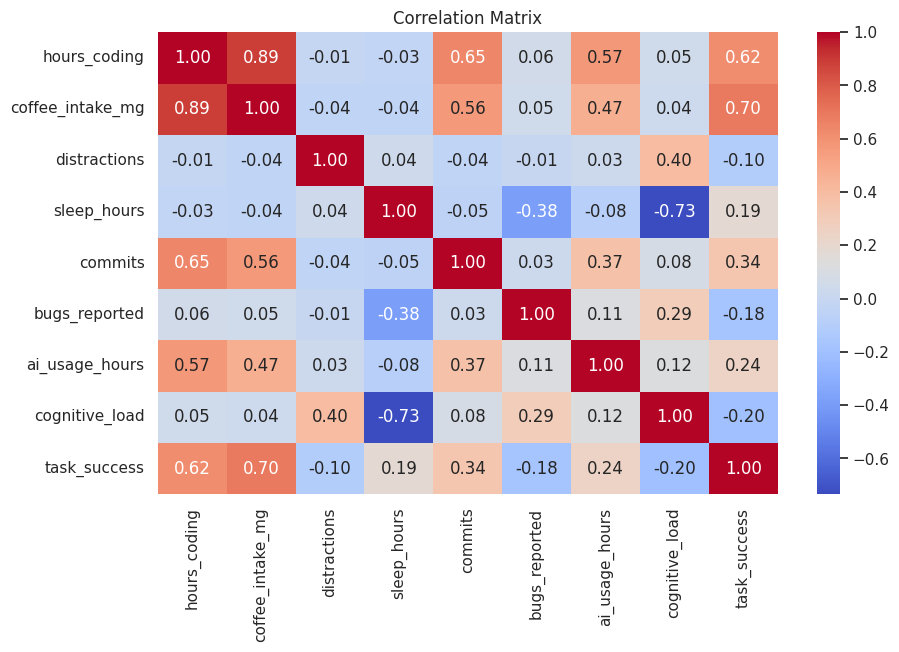

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

### View Boxplot of Sleep Hours vs Task Success

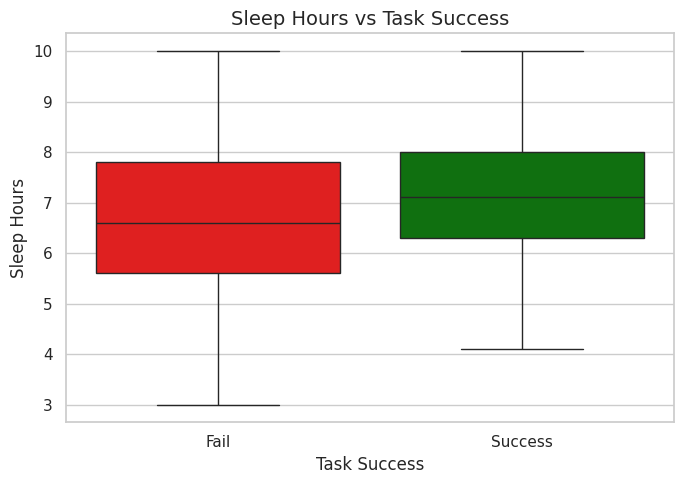

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn styling
sns.set(style="whitegrid")

# Boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(
    x='task_success', y='sleep_hours', hue='task_success',
    data=df, palette={0: 'red', 1: 'green'}, legend=False
)
plt.title("Sleep Hours vs Task Success", fontsize=14)
plt.xlabel("Task Success", fontsize=12)
plt.ylabel("Sleep Hours", fontsize=12)
plt.xticks([0, 1], ['Fail', 'Success'])
plt.tight_layout()
plt.show()

In [ ]:
# Calculate median sleep_hours
medians = df.groupby('task_success')['sleep_hours'].median()
print(medians)

task_success
0    6.6
1    7.1
Name: sleep_hours, dtype: float64


### View Barplot of AI Usage Hours vs Task Success

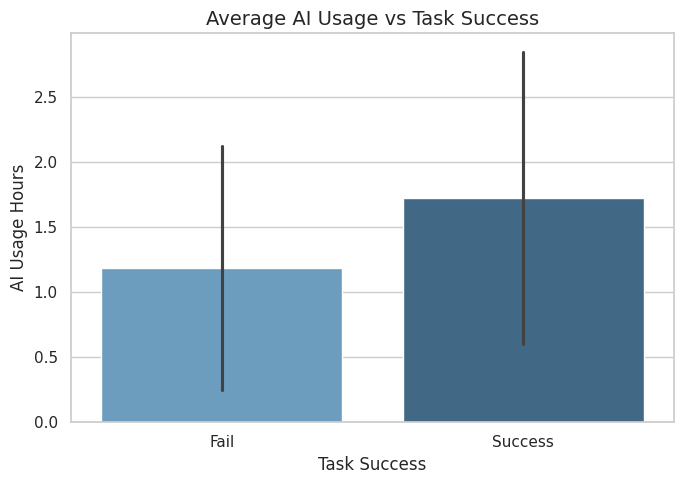

In [ ]:
# Barplot of AI Usage
plt.figure(figsize=(7, 5))
sns.barplot(
    x='task_success', y='ai_usage_hours', hue='task_success',
    data=df, palette='Blues_d', errorbar='sd', legend=False
)
plt.title("Average AI Usage vs Task Success", fontsize=14)
plt.xlabel("Task Success", fontsize=12)
plt.ylabel("AI Usage Hours", fontsize=12)
plt.xticks([0, 1], ['Fail', 'Success'])
plt.tight_layout()
plt.show()

In [ ]:
# Calculate average distractions for fail and success
ai_mean = df.groupby('task_success')['ai_usage_hours'].mean()
print(ai_mean)

task_success
0    1.185888
1    1.722244
Name: ai_usage_hours, dtype: float64


### View Barplot of Distractions vs Task Success

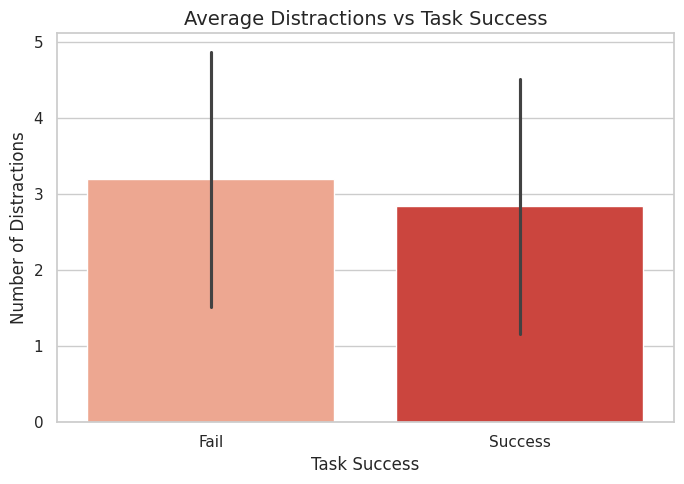

In [ ]:
# Barplot of Distractions
plt.figure(figsize=(7, 5))
sns.barplot(
    x='task_success', y='distractions', hue='task_success',
    data=df, palette='Reds', errorbar='sd', legend=False
)
plt.title("Average Distractions vs Task Success", fontsize=14)
plt.xlabel("Task Success", fontsize=12)
plt.ylabel("Number of Distractions", fontsize=12)
plt.xticks([0, 1], ['Fail', 'Success'])
plt.tight_layout()
plt.show()

In [ ]:
# Calculate average distractions for fail and success
distractions_mean = df.groupby('task_success')['distractions'].mean()
print(distractions_mean)

task_success
0    3.192893
1    2.834983
Name: distractions, dtype: float64


### View Barplot of Average Coffee Intake vs Task Success

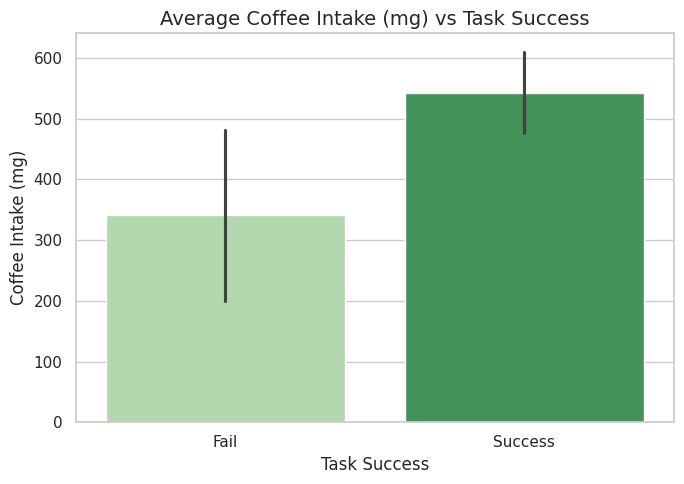

In [ ]:
# Barplot of Coffee Intake (mg)
plt.figure(figsize=(7, 5))
sns.barplot(
    x='task_success', y='coffee_intake_mg', hue='task_success',
    data=df, palette='Greens', errorbar='sd', legend=False
)
plt.title("Average Coffee Intake (mg) vs Task Success", fontsize=14)
plt.xlabel("Task Success", fontsize=12)
plt.ylabel("Coffee Intake (mg)", fontsize=12)
plt.xticks([0, 1], ['Fail', 'Success'])
plt.tight_layout()
plt.show()

In [ ]:
# Calculate average coffee intake (mg)
coffee_mean = df.groupby('task_success')['coffee_intake_mg'].mean()
print(coffee_mean)

task_success
0    340.598985
1    542.897690
Name: coffee_intake_mg, dtype: float64


### View Barplot of Average Hours Coding vs Task Success

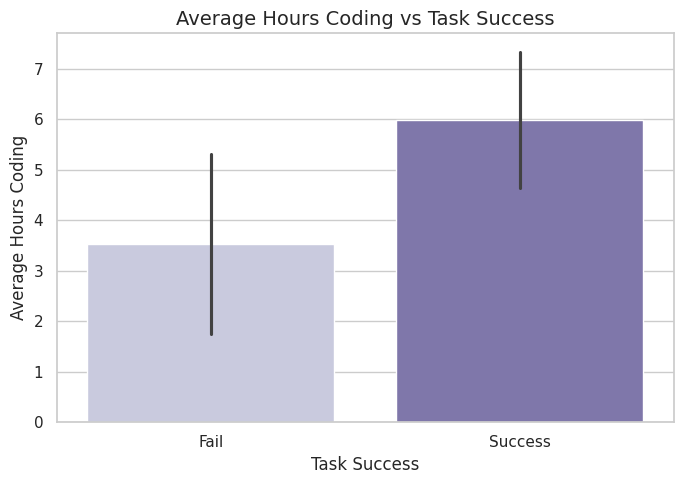

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x='task_success', y='hours_coding', hue='task_success',
    data=df, palette='Purples', errorbar='sd', legend=False
)
plt.title("Average Hours Coding vs Task Success", fontsize=14)
plt.xlabel("Task Success", fontsize=12)
plt.ylabel("Average Hours Coding", fontsize=12)
plt.xticks([0, 1], ['Fail', 'Success'])
plt.tight_layout()
plt.show()

In [ ]:
# Calculate average hours coding
coding_mean = df.groupby('task_success')['hours_coding'].mean()
print(coding_mean)

task_success
0    3.530609
1    5.981089
Name: hours_coding, dtype: float64


# 4. Prepare to Apply Supervised Learning Models!

## Set Target and Features

In [ ]:
X = df.drop(columns=['task_success']) # Features
y = df['task_success'] # Target

## Scale Features for Logistic Regression

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Split Data into Training and Testing Subsets

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Build Model! - Logistic Regression

## Logistic Regression

In [ ]:
# Logistic Regression Model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)

# Calculate Accuracy
test_accuracy = accuracy_score(y_test, y_pred_log)
print(f"\nTest Accuracy: {test_accuracy:.2%}")


Test Accuracy: 85.00%


## Show Results

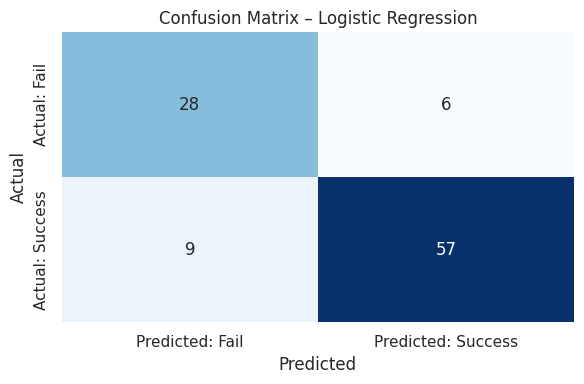

Logistic Regression Results
[[28  6]
 [ 9 57]]
              precision    recall  f1-score   support

           0       0.76      0.82      0.79        34
           1       0.90      0.86      0.88        66

    accuracy                           0.85       100
   macro avg       0.83      0.84      0.84       100
weighted avg       0.85      0.85      0.85       100



In [ ]:
# Get confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Heatmap of Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Fail', 'Predicted: Success'],
            yticklabels=['Actual: Fail', 'Actual: Success'])

plt.title('Confusion Matrix – Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


print("Logistic Regression Results")
print(cm)
print(classification_report(y_test, y_pred_log))

## Make Predictions on the Training Data

## Calculate Accuracy

In [ ]:
y_train_pred = logreg.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2%}")

Training Accuracy: 89.00%


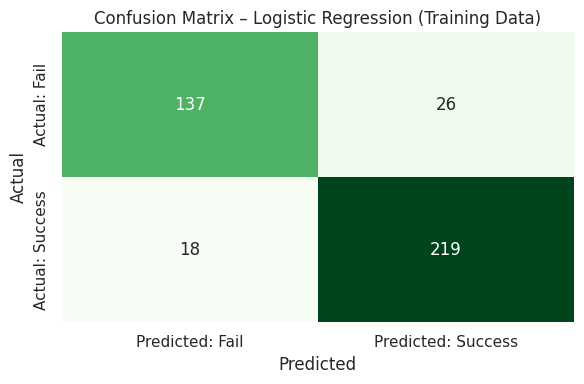

In [ ]:
cm_train = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted: Fail', 'Predicted: Success'],
            yticklabels=['Actual: Fail', 'Actual: Success'])

plt.title('Confusion Matrix – Logistic Regression (Training Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 6. Build Model! - Random Forest

In [ ]:
# Random Forest Model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test)

## Show Results

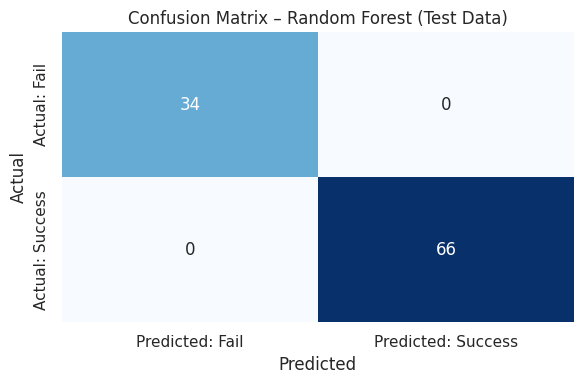

In [ ]:
# Create confusion matrix
cm_test_rf = confusion_matrix(y_test, y_pred_rf)

# Plot test confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Fail', 'Predicted: Success'],
            yticklabels=['Actual: Fail', 'Actual: Success'])

plt.title('Confusion Matrix – Random Forest (Test Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
[[34  0]
 [ 0 66]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        66

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



### Predict on Training data

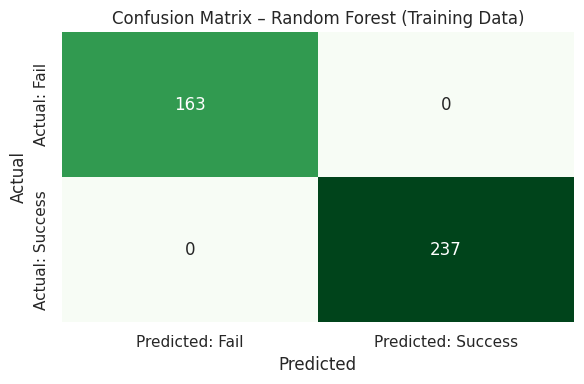

In [ ]:
# Predict on training set
y_train_pred_rf = rf.predict(X_train)

# Create confusion matrix
cm_train_rf = confusion_matrix(y_train, y_train_pred_rf)

# Plot training confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_train_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted: Fail', 'Predicted: Success'],
            yticklabels=['Actual: Fail', 'Actual: Success'])

plt.title('Confusion Matrix – Random Forest (Training Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 7. Analyse Models' ROC Curve

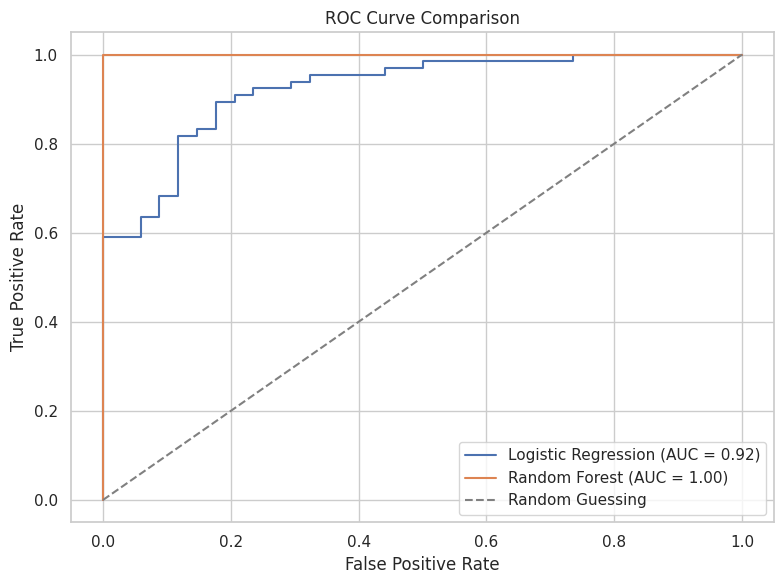

In [ ]:
# Logistic Regression predicted probabilities for class 1
y_probs_log = logreg.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_log)
roc_auc_log = auc(fpr_log, tpr_log)

# Random Forest predicted probabilities for class 1
y_probs_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot both ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


# 8. Analyse Feature Importances

### Feature Importances (Logistic Regression)

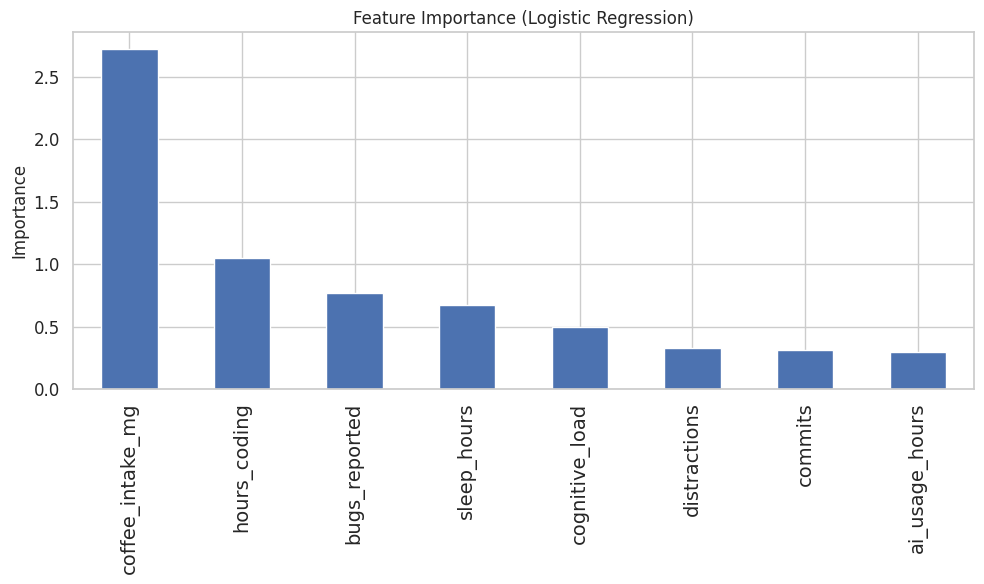

In [ ]:
# Get feature names
feat_names = df.drop(columns='task_success').columns

# Get model coefficients (from scaled data)
coefficients = logreg.coef_[0]  # Get 1D array of coefficients

# Create a pandas Series with absolute values
feat_imp_log = pd.Series(np.abs(coefficients), index=feat_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
feat_imp_log.plot(kind='bar')
plt.title("Feature Importance (Logistic Regression)")
plt.ylabel("Importance")
plt.xticks(fontsize=14)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### Feature Importances (Random Forest)


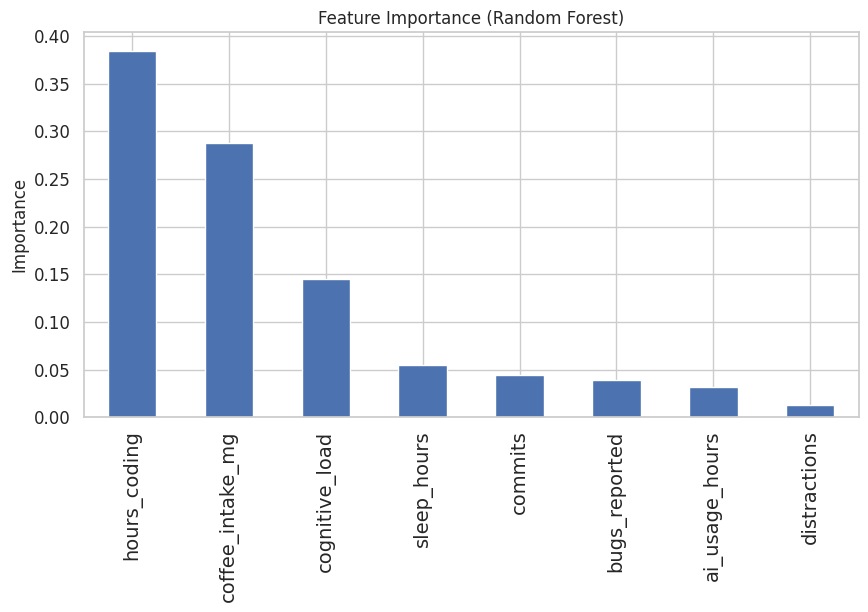

In [ ]:
# Feature Importances
importances = rf.feature_importances_
feat_names = df.drop(columns='task_success').columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.xticks(fontsize=14)
plt.yticks(fontsize=12)
plt.ylabel("Importance")
plt.show()
